# Inference Pipeline
---
## Auto-Annotation Model

In [1]:
import torch
import torchvision

# set device to cpu
device = torch.device('cpu')

# load pre-trained model
annotation_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 2  # Background + Text

# set classification head to pre-trained model
in_features = annotation_model.roi_heads.box_predictor.cls_score.in_features
annotation_model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# load the fine-tuned model
annotation_model.load_state_dict(torch.load('/kaggle/input/annotation_model/pytorch/default/4/annotation_model.pth', 
                                            map_location=device, weights_only=True))

<All keys matched successfully>

In [2]:
import cv2
import torchvision.transforms as T

def predict_and_visualize(model, image_path, device, threshold=0.8):
    # load image
    image = cv2.imread(image_path)
    orig_image = image.copy()
    
    # transform image to tensor
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # prediction
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    # extract boxes and scores
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()

    # keep boxes above threshold
    true_boxes = []
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            true_boxes.append(box)
    
    # draw bounding boxes on the image
    for i, box in enumerate(true_boxes):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    return image, sorted(true_boxes, key=lambda x: x[1]), orig_image

## OCR Model

In [3]:
import torch.nn as nn

class HandwritingRecognitionModel(nn.Module):
    def __init__(self, num_characters):
        super(HandwritingRecognitionModel, self).__init__()
        
        self.cnn = nn.Sequential(
            # first CNN layer
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AvgPool2d(2,2),
            nn.Dropout2d(0.5),
            
            # second CNN layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AvgPool2d(2,2),
            nn.Dropout2d(0.5),
            
            # third CNN layer
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            
            # fourth CNN layer
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.5),

            # fifth CNN layer
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.lstm_input_size = 512 * 12
        
        # bi-LSTM network
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=256,
            dropout=0.7,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        
        self.output = nn.Linear(512, num_characters)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        x = x.permute(0, 3, 1, 2)
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, x.size(1), -1)
        x, _ = self.lstm(x)
        x = self.output(x)
        
        return nn.functional.log_softmax(x, dim=2)

def build_model(num_characters):
    return HandwritingRecognitionModel(num_characters)

In [4]:
import pickle

# load the decoder
with open('/kaggle/input/first_model/pytorch/default/6/num_to_char.pkl', 'rb') as f:
    num_to_char = pickle.load(f)

# initialise model
num_characters = len(num_to_char)
model = HandwritingRecognitionModel(num_characters)

# load the trained OCR model
model_path = "/kaggle/input/first_model/pytorch/default/6/model_state.pth"
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

HandwritingRecognitionModel(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Dropout2d(p=0.5, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (9): Dropout2d(p=0.5, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.5, inplace=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## Inference pipeline

In [5]:
import numpy as np

# set fixed input height
FIXED_HEIGHT = 45

def preprocess_crop(image, box):
    x1, y1, x2, y2 = map(int, box)
    crop = image[y1:y2, x1:x2]
    
    h = y2-y1
    w = x2-x1
    
    aspect_ratio = w / h if h != 0 else 1
    new_width = max(1, int(FIXED_HEIGHT * aspect_ratio))
    
    resized = cv2.resize(crop, (new_width, FIXED_HEIGHT))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    normalized = gray.astype(np.float32) / 255.0
    normalized = np.expand_dims(normalized, axis=-1)
    
    return normalized

In [6]:
def collate_inference_images(image_tensors):
    widths = [img.shape[1] for img in image_tensors]
    max_width = max(widths)

    # pad tensors to max width
    padded_images = []
    for img in image_tensors:
        pad_width = max_width - img.shape[1]
        padded = np.pad(img, ((0, 0), (0, pad_width), (0, 0)), mode='constant', constant_values=0)
        padded_images.append(padded)

    batch = np.stack(padded_images, axis=0)
    return torch.tensor(batch, dtype=torch.float32)

In [7]:
def decode_predictions(preds, num_to_char):
    pred_indices = torch.argmax(preds, dim=2).detach().cpu().numpy()

    # decode predictions
    decoded = []
    for indices in pred_indices:
        prev_idx = None
        chars = []
        for idx in indices:
            if idx != prev_idx and idx != 0:  # 0 is <PAD>
                chars.append(num_to_char.get(idx, ''))
            prev_idx = idx
        decoded.append("".join(chars))
        
    return decoded

In [8]:
def run_inference(model, image, bboxes, num_to_char, device=device):
    image_tensors = [preprocess_crop(image, box) for box in bboxes]
    batch = collate_inference_images(image_tensors).to(device)
    batch = batch.contiguous()

    with torch.no_grad():
        preds = model(batch)
    decoded_strings = decode_predictions(preds, num_to_char)
    
    return decoded_strings

In [9]:
from textblob import TextBlob

def transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8):
    # run auto-annotator
    image, boxes, orig_image = predict_and_visualize(annotation_model, input, device, threshold=0.8)
    
    # run OCR prediction
    results = run_inference(model, image, boxes, num_to_char)
    text = " ".join(results)

    # replacement dictionary
    replace_dict = {"  ": " ", "   ": " ", " t ":" ", " f ":" ", " b ":" ", " d ":" ",
                   " m ":" ", " s ":" "}
    
    # loop to replace
    for old, new in replace_dict.items():
        text = text.replace(old, new)

    # correct the spelling
    blob = TextBlob(text)
    corrected_text = blob.correct()
    
    return corrected_text, orig_image

## Run Inference

In [10]:
input = '/kaggle/input/resized-journal-scans/resized_journal_scans/IMG_6240.JPG'

s/07/tom Humanity faces many threats to but eradicated. Civilzations, rose and fell many time in the history of the earth The threats we and facing are new, but they ought to bet expected per this natural cycle Had since so many civilightions have collapsed, there was another that rose after. Humanity has at tendency to survive and thrive once more. Therefore, there is no nest to fret, because this is natural occupant. Threat that is possible but less likely is the extinction on humans as a species. It is appereannt in nature that this is possible om It is a lot less probable, but still possible and perhaps not more than ever. Obviously, humane like any then animal have an instinct to survive. To it good to know that it ism unlikely, but also important to know the risks from

Inference time: 17.87 seconds



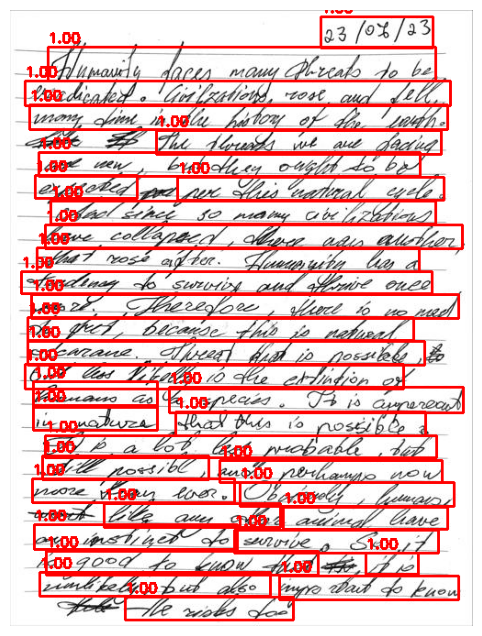

In [11]:
import time
import matplotlib.pyplot as plt

start = time.time()
text, orig_image = transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8)

# output transcribed text
print(text)
print('\nInference time:', round(time.time() - start, 2), 'seconds\n')

# plot bounding boxes
plt.figure(figsize=(12, 8))
plt.imshow(orig_image)
plt.axis("off")
plt.show()